# Worksheet 6 Notebook: Image Classification with CNN and Transfer Learning

This notebook is designed for **Worksheet 6** and uses the **FruitInAmazon** dataset.

Key fixes applied in this version:
- balanced **stratified** train/validation split for the tiny dataset
- lighter custom CNN baseline that no longer collapses during training
- frozen **VGG16** transfer-learning pipeline aligned with the worksheet

The goal is not just to train a model, but to build a pipeline that is stable and interpretable on a very small image dataset.



## 1. Import Libraries

In [1]:
import os
import random
from collections import Counter
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import tensorflow as tf

from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers, Sequential
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

SEED = 1337
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)



TensorFlow version: 2.21.0


## 2. Dataset Configuration

The notebook assumes the dataset has this structure:

```text
FruitinAmazon/
  FruitinAmazon/
    train/
      acai/
      cupuacu/
      graviola/
      guarana/
      pupunha/
      tucuma/
    test/
      acai/
      cupuacu/
      graviola/
      guarana/
      pupunha/
      tucuma/
```

In [2]:
# =========================
# UPDATE THIS PATH IF NEEDED
# =========================
dataset_root = Path("FruitinAmazon/FruitinAmazon")

train_dir = dataset_root / "train"
test_dir = dataset_root / "test"

CUSTOM_IMAGE_SIZE = (160, 160)
TRANSFER_IMAGE_SIZE = (224, 224)
BATCH_SIZE = 16
VALIDATION_SPLIT = 0.2
VALID_EXTENSIONS = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp")
AUTOTUNE = tf.data.AUTOTUNE

print("Train directory:", train_dir.resolve() if train_dir.exists() else train_dir)
print("Test directory :", test_dir.resolve() if test_dir.exists() else test_dir)

if not train_dir.exists():
    print("\n[WARNING] train_dir was not found. Please update dataset_root before running the notebook.")
if not test_dir.exists():
    print("[WARNING] test_dir was not found. Please update dataset_root before running the notebook.")



Train directory: D:\Herald College SEM-6\Artificial Intelligence and Machine Learning\workshop\Workshop6\FruitinAmazon\FruitinAmazon\train
Test directory : D:\Herald College SEM-6\Artificial Intelligence and Machine Learning\workshop\Workshop6\FruitinAmazon\FruitinAmazon\test


## 3. Verify Dataset Structure

In [3]:

train_classes = sorted([item.name for item in train_dir.iterdir() if item.is_dir()]) if train_dir.exists() else []
test_classes = sorted([item.name for item in test_dir.iterdir() if item.is_dir()]) if test_dir.exists() else []

print("Train classes:", train_classes)
print("Test classes :", test_classes)

if train_classes and test_classes:
    if train_classes == test_classes:
        print("\nDataset structure looks correct.")
        print(f"Found {len(train_classes)} classes.")
    else:
        print("\n[WARNING] Train and test classes do not match.")
else:
    print("\nNo classes found yet. Please check your dataset path.")

Train classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Test classes : ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']

Dataset structure looks correct.
Found 6 classes.


## 4. Check for Corrupted Images

In [4]:

def find_corrupted_images(root_dir):
    corrupted = []
    valid_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp")

    if not root_dir.exists():
        return corrupted

    for class_name in sorted(os.listdir(root_dir)):
        class_path = root_dir / class_name
        if not class_path.is_dir():
            continue

        for img_name in os.listdir(class_path):
            if not img_name.lower().endswith(valid_extensions):
                continue

            img_path = class_path / img_name
            try:
                with Image.open(img_path) as img:
                    img.verify()
            except (IOError, UnidentifiedImageError, OSError):
                corrupted.append(str(img_path))
    return corrupted

train_corrupted = find_corrupted_images(train_dir)
test_corrupted = find_corrupted_images(test_dir)

print("Corrupted images in train:", len(train_corrupted))
print("Corrupted images in test :", len(test_corrupted))

if train_corrupted:
    print("\nTrain corrupted images:")
    for path in train_corrupted:
        print(path)

if test_corrupted:
    print("\nTest corrupted images:")
    for path in test_corrupted:
        print(path)

Corrupted images in train: 0
Corrupted images in test : 0


## 5. Class Distribution

In [5]:

def get_class_counts(root_dir):
    class_counts = {}
    valid_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp")

    if not root_dir.exists():
        return class_counts

    for class_name in sorted(os.listdir(root_dir)):
        class_path = root_dir / class_name
        if class_path.is_dir():
            images = [img for img in os.listdir(class_path) if img.lower().endswith(valid_extensions)]
            class_counts[class_name] = len(images)
    return class_counts

train_class_counts = get_class_counts(train_dir)
test_class_counts = get_class_counts(test_dir)

print("Training Class Distribution")
print("=" * 45)
print(f"{'Class Name':<25}{'Image Count':>15}")
print("=" * 45)
for class_name, count in train_class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)

print("\nTesting Class Distribution")
print("=" * 45)
print(f"{'Class Name':<25}{'Image Count':>15}")
print("=" * 45)
for class_name, count in test_class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("=" * 45)

Training Class Distribution
Class Name                   Image Count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15

Testing Class Distribution
Class Name                   Image Count
acai                                   5
cupuacu                                5
graviola                               5
guarana                                5
pupunha                                5
tucuma                                 5


## 6. Visualize One Random Image from Each Class

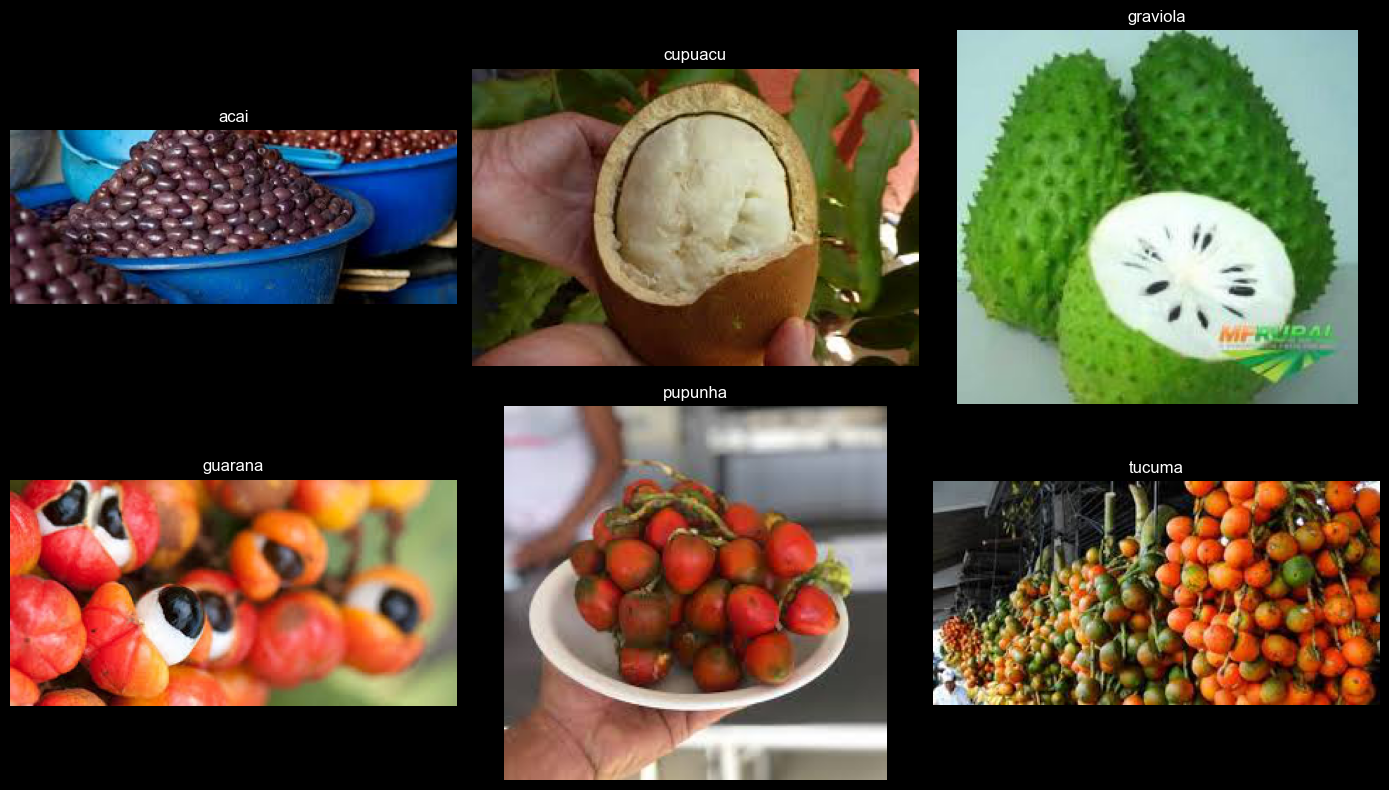

In [6]:

selected_images = []
selected_labels = []
valid_extensions = (".png", ".jpg", ".jpeg", ".bmp", ".gif", ".webp")

for class_name in train_classes:
    class_path = train_dir / class_name
    if class_path.is_dir():
        images = [img for img in os.listdir(class_path) if img.lower().endswith(valid_extensions)]
        if images:
            selected_img = class_path / random.choice(images)
            selected_images.append(selected_img)
            selected_labels.append(class_name)

num_classes = len(selected_images)
cols = 3
rows = int(np.ceil(num_classes / cols)) if num_classes > 0 else 1

plt.figure(figsize=(14, 4 * rows))
for i, (img_path, label) in enumerate(zip(selected_images, selected_labels), start=1):
    plt.subplot(rows, cols, i)
    img = mpimg.imread(img_path)
    plt.imshow(img)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Create Stratified Train, Validation, and Test Pipelines

`image_dataset_from_directory(validation_split=...)` is convenient, but on this tiny dataset it can create an imbalanced validation subset.
To keep validation fair, we split the file paths manually with `train_test_split(..., stratify=labels)`.



In [7]:
def collect_image_paths(root_dir, class_names):
    image_paths = []
    labels = []
    class_to_index = {class_name: idx for idx, class_name in enumerate(class_names)}

    for class_name in class_names:
        class_path = root_dir / class_name
        for img_path in sorted(class_path.iterdir()):
            if img_path.is_file() and img_path.suffix.lower() in VALID_EXTENSIONS:
                image_paths.append(str(img_path))
                labels.append(class_to_index[class_name])

    return image_paths, labels


train_image_paths, train_labels_all = collect_image_paths(train_dir, train_classes)
test_image_paths, test_labels = collect_image_paths(test_dir, test_classes)

train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_image_paths,
    train_labels_all,
    test_size=VALIDATION_SPLIT,
    random_state=SEED,
    stratify=train_labels_all
)


def show_split_counts(split_name, labels, class_names):
    counts = Counter(labels)
    print(f"{split_name} split:")
    for idx, class_name in enumerate(class_names):
        print(f"  {class_name:<10} -> {counts[idx]}")
    print(f"  total      -> {len(labels)}\n")


@tf.autograph.experimental.do_not_convert
def load_and_resize_image(path, label, image_size):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, image_size)
    image.set_shape(image_size + (3,))
    return tf.cast(image, tf.float32), tf.cast(label, tf.int32)


def build_dataset(image_paths, labels, image_size, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        ds = ds.shuffle(len(image_paths), seed=SEED, reshuffle_each_iteration=True)

    ds = ds.map(
        lambda path, label: load_and_resize_image(path, label, image_size),
        num_parallel_calls=AUTOTUNE
    )
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds


class_names = train_classes
num_classes = len(class_names)

custom_train_ds = build_dataset(train_paths, train_labels, CUSTOM_IMAGE_SIZE, training=True)
custom_val_ds = build_dataset(val_paths, val_labels, CUSTOM_IMAGE_SIZE)
custom_test_ds = build_dataset(test_image_paths, test_labels, CUSTOM_IMAGE_SIZE)

transfer_train_ds = build_dataset(train_paths, train_labels, TRANSFER_IMAGE_SIZE, training=True)
transfer_val_ds = build_dataset(val_paths, val_labels, TRANSFER_IMAGE_SIZE)
transfer_test_ds = build_dataset(test_image_paths, test_labels, TRANSFER_IMAGE_SIZE)

show_split_counts("Train", train_labels, class_names)
show_split_counts("Validation", val_labels, class_names)
show_split_counts("Test", test_labels, class_names)

print("Class names:", class_names)
print("Number of classes:", num_classes)



Train split:
  acai       -> 12
  cupuacu    -> 12
  graviola   -> 12
  guarana    -> 12
  pupunha    -> 12
  tucuma     -> 12
  total      -> 72

Validation split:
  acai       -> 3
  cupuacu    -> 3
  graviola   -> 3
  guarana    -> 3
  pupunha    -> 3
  tucuma     -> 3
  total      -> 18

Test split:
  acai       -> 5
  cupuacu    -> 5
  graviola   -> 5
  guarana    -> 5
  pupunha    -> 5
  tucuma     -> 5
  total      -> 30

Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Number of classes: 6


## 8. Inspect a Batch

In [8]:
for images, labels in custom_train_ds.take(1):
    print("Custom train images shape:", images.shape)
    print("Custom train labels shape:", labels.shape)

for images, labels in transfer_train_ds.take(1):
    print("Transfer train images shape:", images.shape)
    print("Transfer train labels shape:", labels.shape)



Custom train images shape: (16, 160, 160, 3)
Custom train labels shape: (16,)
Transfer train images shape: (16, 224, 224, 3)
Transfer train labels shape: (16,)


## 9. Visualize Training Batch

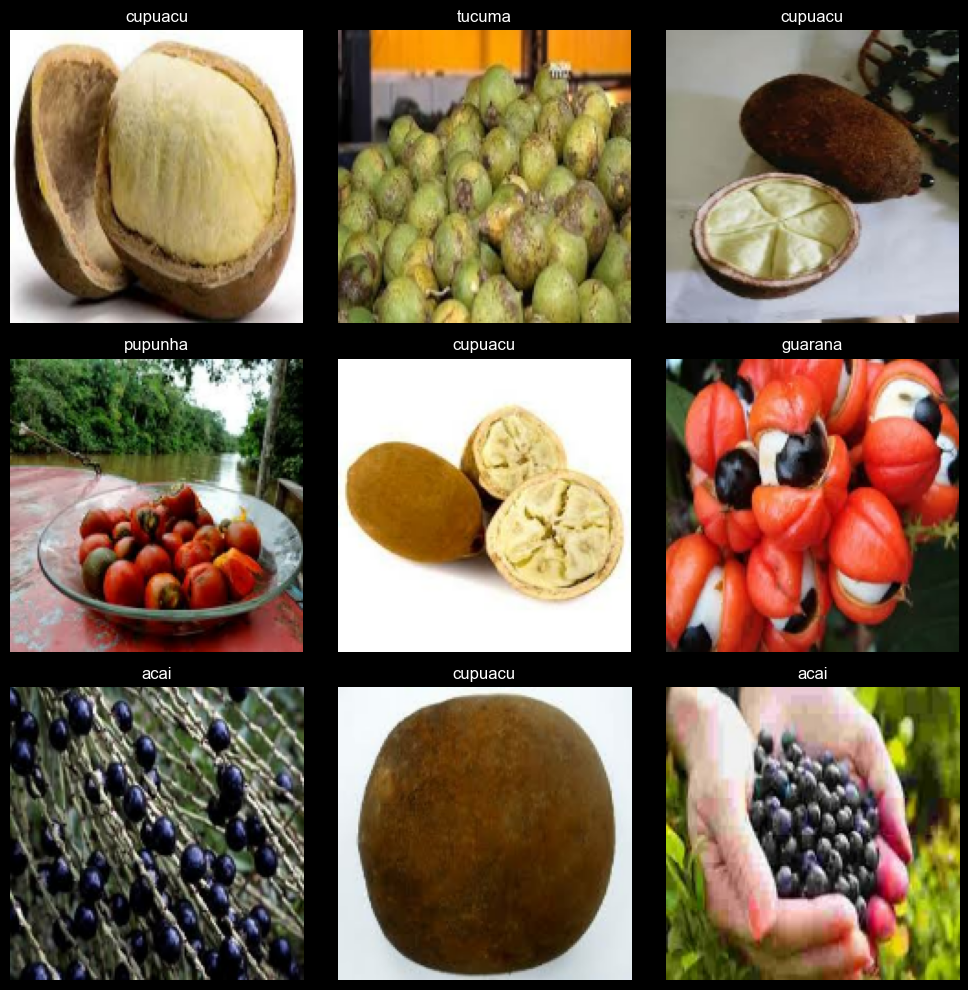

In [9]:
plt.figure(figsize=(10, 10))
for images, labels in custom_train_ds.take(1):
    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(np.array(images[i]).astype("uint8"))
        plt.title(class_names[int(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()



## 10. tf.data Performance Setup

The dataset helper already applies `shuffle`, `batch`, and `prefetch`, so the pipelines are ready for training as soon as they are created.



In [10]:
print("custom_train_ds/custom_val_ds/custom_test_ds are already shuffled, batched, and prefetched.")
print("transfer_train_ds/transfer_val_ds/transfer_test_ds are already shuffled, batched, and prefetched.")



custom_train_ds/custom_val_ds/custom_test_ds are already shuffled, batched, and prefetched.
transfer_train_ds/transfer_val_ds/transfer_test_ds are already shuffled, batched, and prefetched.


## 11. Data Augmentation

For the custom CNN, a **light** augmentation policy works better on this very small dataset.
Heavier augmentation was tested and reduced validation performance.



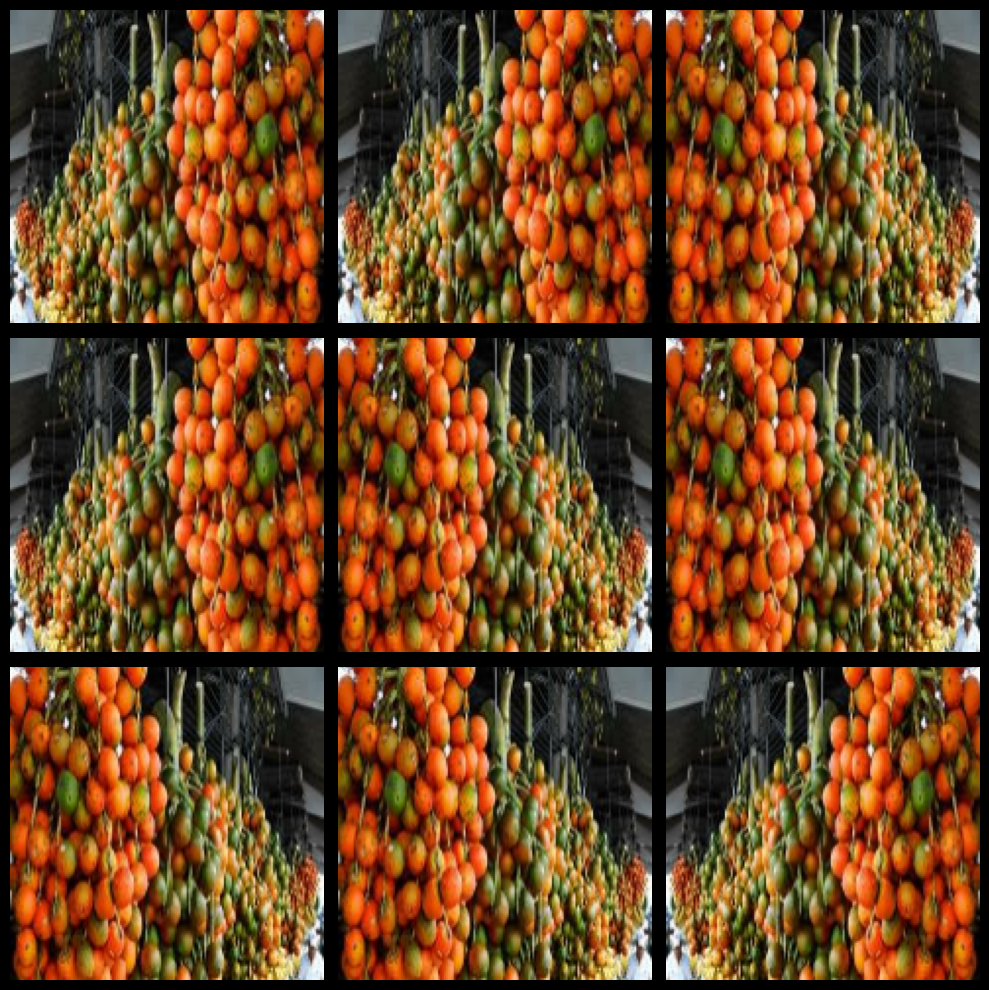

In [11]:
custom_data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
], name="custom_data_augmentation")

plt.figure(figsize=(10, 10))
for images, _ in custom_train_ds.take(1):
    first_image = images[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = custom_data_augmentation(tf.expand_dims(first_image, axis=0), training=True)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")
plt.tight_layout()
plt.show()



# Task 1: CNN from Scratch with Batch Normalization and Dropout

## 12. Build a Compact CNN Baseline

The original notebook used a very large flatten-based CNN, which is too heavy for only **72 training images** after validation split.
This compact baseline keeps the model trainable from scratch while avoiding the severe overfitting seen before.



In [12]:
def build_custom_cnn(input_shape=(160, 160, 3), num_classes=6):
    model = Sequential([
        layers.Input(shape=input_shape),
        custom_data_augmentation,
        layers.Rescaling(1.0 / 255),

        layers.Conv2D(16, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
        layers.GlobalAveragePooling2D(),

        layers.Dropout(0.3),
        layers.Dense(64, activation="relu"),
        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ], name="custom_fruit_cnn")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model


custom_cnn = build_custom_cnn(input_shape=CUSTOM_IMAGE_SIZE + (3,), num_classes=num_classes)
custom_cnn.summary()



Model: "custom_fruit_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ custom_data_augmentation        │ (None, 160, 160, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 160, 160, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 160, 160, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 80, 80, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 80, 80, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 40, 40, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 40, 40, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 106,086 (414.40 KB)

 Trainable params: 106,086 (414.40 KB)

 Non-trainable params: 0 (0.00 B)

## 13. Train the Custom CNN

In [13]:
custom_checkpoint_path = "best_custom_fruit_cnn.keras"

custom_callbacks = [
    EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    ModelCheckpoint(custom_checkpoint_path, monitor="val_accuracy", save_best_only=True, verbose=1)
]

custom_history = custom_cnn.fit(
    custom_train_ds,
    validation_data=custom_val_ds,
    epochs=30,
    callbacks=custom_callbacks
)



Epoch 1/30
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.0859 - loss: 1.8026
Epoch 1: val_accuracy improved from None to 0.16667, saving model to best_custom_fruit_cnn.keras

Epoch 1: finished saving model to best_custom_fruit_cnn.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.1111 - loss: 1.7986 - val_accuracy: 0.1667 - val_loss: 1.7894 - learning_rate: 0.0010
Epoch 2/30
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.2448 - loss: 1.7860
Epoch 2: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.1944 - loss: 1.7879 - val_accuracy: 0.1667 - val_loss: 1.7834 - learning_rate: 0.0010
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.1542 - loss: 1.7953
Epoch 3: val_accuracy did not improve from 0.16667
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.1667 - loss: 1.7895 - val_accuracy: 0.1667 - val_loss: 1.7775 - learning_rate: 0.0010
Epoch 4/30
4/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.1484 - loss

## 14. Plot Custom CNN Training Curves

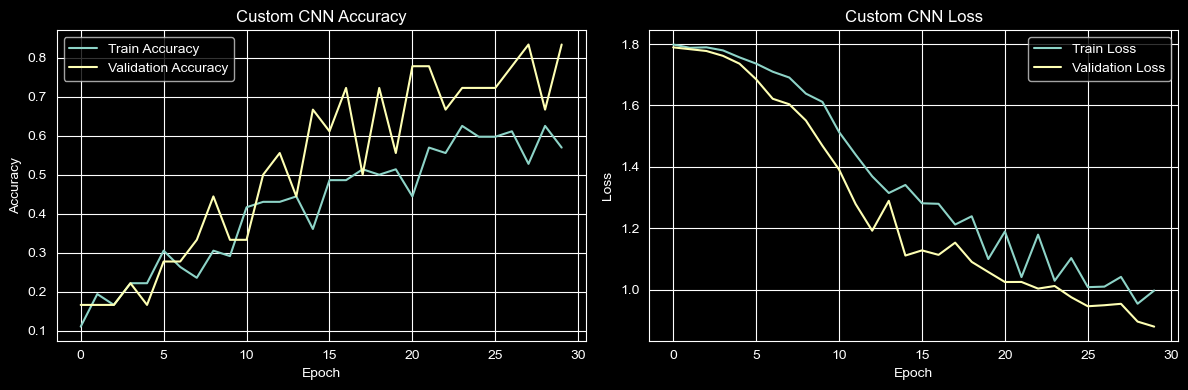

In [14]:

history_dict = custom_history.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.title("Custom CNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.title("Custom CNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 15. Evaluate the Custom CNN

In [15]:
custom_val_loss, custom_val_acc = custom_cnn.evaluate(custom_val_ds, verbose=0)
custom_test_loss, custom_test_acc = custom_cnn.evaluate(custom_test_ds, verbose=0)

print(f"Custom CNN Validation Accuracy: {custom_val_acc:.4f}")
print(f"Custom CNN Test Accuracy      : {custom_test_acc:.4f}")



Custom CNN Validation Accuracy: 0.8333
Custom CNN Test Accuracy      : 0.6000


## 16. Classification Report for the Custom CNN

In [27]:
y_true_custom = np.concatenate([labels.numpy() for _, labels in custom_test_ds], axis=0)
y_prob_custom = custom_cnn.predict(custom_test_ds)
y_pred_custom = np.argmax(y_prob_custom, axis=1)

print("Custom CNN Classification Report")
print(classification_report(y_true_custom, y_pred_custom, target_names=class_names, zero_division=0))





2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Custom CNN Classification Report
              precision    recall  f1-score   support

        acai       0.71      1.00      0.83         5
     cupuacu       0.33      0.20      0.25         5
    graviola       0.67      0.80      0.73         5
     guarana       0.56      1.00      0.71         5
     pupunha       1.00      0.20      0.33         5
      tucuma       0.50      0.40      0.44         5

    accuracy                           0.60        30
   macro avg       0.63      0.60      0.55        30
weighted avg       0.63      0.60      0.55        30



## 17. Sample Inference Output for the Custom CNN

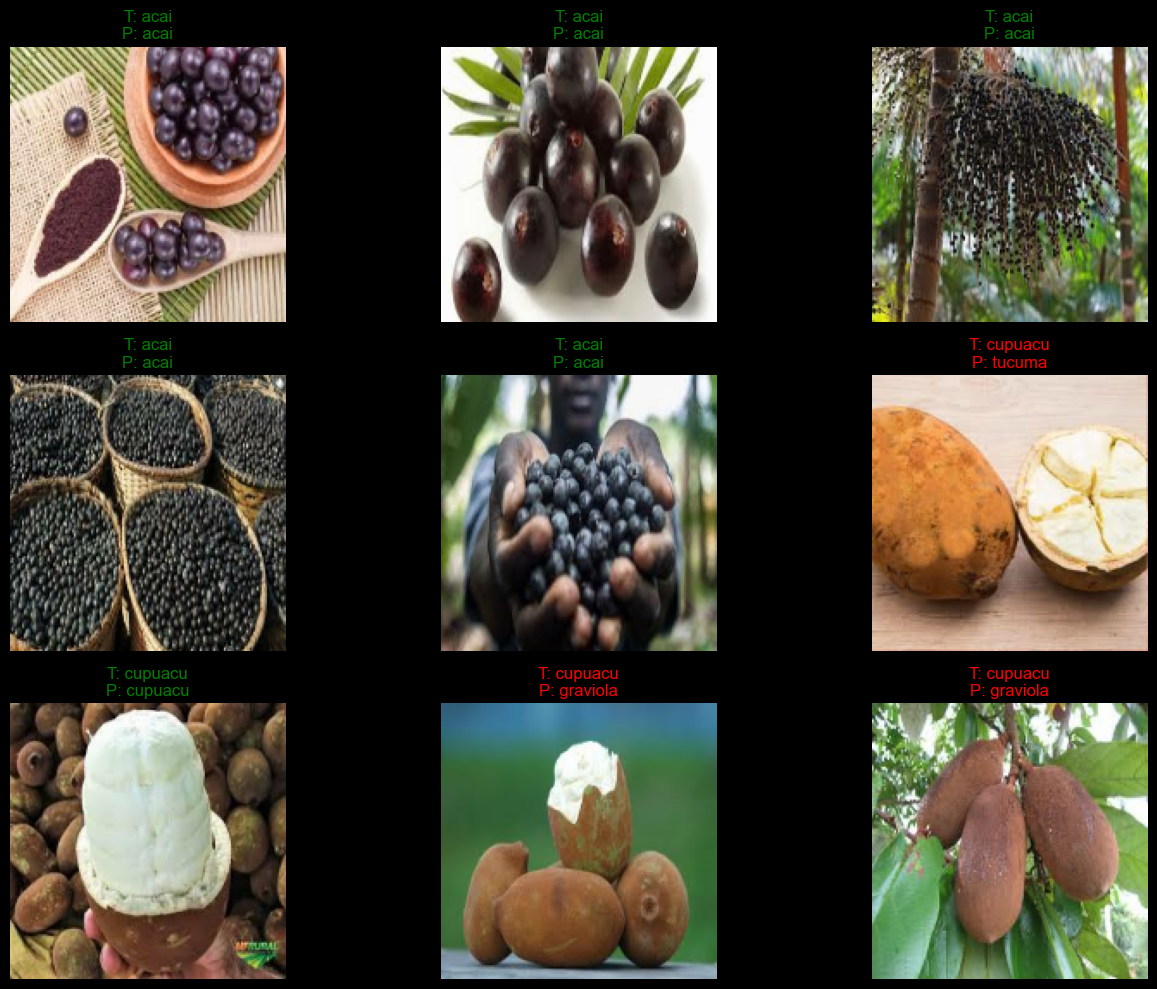

In [17]:
plt.figure(figsize=(14, 10))
for images, labels in custom_test_ds.take(1):
    preds = custom_cnn.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_name = class_names[int(labels[i])]
        pred_name = class_names[int(pred_labels[i])]
        color = "green" if true_name == pred_name else "red"
        plt.title(f"T: {true_name}\nP: {pred_name}", color=color)
        plt.axis("off")
plt.tight_layout()
plt.show()



## 18. Save the Custom CNN Model

In [18]:

custom_model_path = Path("fruit_custom_cnn_final.keras")
custom_cnn.save(custom_model_path)
print("Saved custom CNN model to:", custom_model_path.resolve())

Saved custom CNN model to: D:\Herald College SEM-6\Artificial Intelligence and Machine Learning\workshop\Workshop6\fruit_custom_cnn_final.keras


# Task 2: Transfer Learning with VGG16

## 19. Build the VGG16 Transfer Learning Model

This model follows the worksheet requirement: use **ImageNet pre-trained VGG16**, freeze the convolutional base, and train only the new classification head.



In [19]:
transfer_data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.08),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="transfer_data_augmentation")

base_model = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=TRANSFER_IMAGE_SIZE + (3,)
)

base_model.trainable = False

inputs = keras.Input(shape=TRANSFER_IMAGE_SIZE + (3,))
x = transfer_data_augmentation(inputs)
x = layers.Lambda(preprocess_input)(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

vgg_model = keras.Model(inputs, outputs, name="fruit_vgg16_transfer")

vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

vgg_model.summary()



Model: "fruit_vgg16_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transfer_data_augmentation      │ (None, 224, 224, 3)    │             0 │
│ (Sequential)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,849,606 (56.65 MB)

 Trainable params: 133,894 (523.02 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

## 20. Train the VGG16 Model

In [20]:
vgg_checkpoint_path = "best_vgg16_fruit_model.keras"

vgg_callbacks = [
    EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, verbose=1),
    ModelCheckpoint(vgg_checkpoint_path, monitor="val_accuracy", save_best_only=True, verbose=1)
]

vgg_history = vgg_model.fit(
    transfer_train_ds,
    validation_data=transfer_val_ds,
    epochs=15,
    callbacks=vgg_callbacks
)



Epoch 1/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3052 - loss: 2.2187
Epoch 1: val_accuracy improved from None to 0.44444, saving model to best_vgg16_fruit_model.keras

Epoch 1: finished saving model to best_vgg16_fruit_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.2917 - loss: 2.1332 - val_accuracy: 0.4444 - val_loss: 2.1356 - learning_rate: 3.0000e-04
Epoch 2/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3059 - loss: 1.9787
Epoch 2: val_accuracy improved from 0.44444 to 0.55556, saving model to best_vgg16_fruit_model.keras

Epoch 2: finished saving model to best_vgg16_fruit_model.keras
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step - accuracy: 0.3472 - loss: 1.9525 - val_accuracy: 0.5556 - val_loss: 1.2672 - learning_rate: 3.0000e-04
Epoch 3/15
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 960ms/step - accuracy: 0.4351 - loss: 1.7297
Epoch 3: val_accuracy improved from 0.55556 to 0.66667, saving model to best_vgg16_fruit_model.keras

Epoch 3: finished saving model to best_vgg16

## 21. Plot VGG16 Training Curves

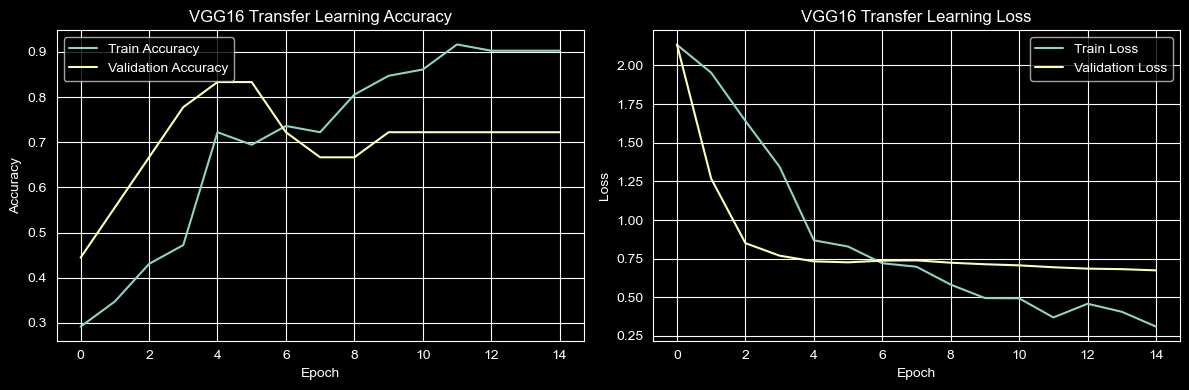

In [21]:

history_dict = vgg_history.history

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_dict["accuracy"], label="Train Accuracy")
plt.plot(history_dict["val_accuracy"], label="Validation Accuracy")
plt.title("VGG16 Transfer Learning Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_dict["loss"], label="Train Loss")
plt.plot(history_dict["val_loss"], label="Validation Loss")
plt.title("VGG16 Transfer Learning Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 22. Evaluate the VGG16 Model

In [22]:
vgg_val_loss, vgg_val_acc = vgg_model.evaluate(transfer_val_ds, verbose=0)
vgg_test_loss, vgg_test_acc = vgg_model.evaluate(transfer_test_ds, verbose=0)

print(f"VGG16 Validation Accuracy: {vgg_val_acc:.4f}")
print(f"VGG16 Test Accuracy      : {vgg_test_acc:.4f}")



VGG16 Validation Accuracy: 0.7222
VGG16 Test Accuracy      : 0.8333


## 23. Classification Report for VGG16

In [28]:
y_true_vgg = np.concatenate([labels.numpy() for _, labels in transfer_test_ds], axis=0)
y_prob_vgg = vgg_model.predict(transfer_test_ds)
y_pred_vgg = np.argmax(y_prob_vgg, axis=1)

print("VGG16 Classification Report")
print(classification_report(y_true_vgg, y_pred_vgg, target_names=class_names, zero_division=0))




2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step   
VGG16 Classification Report
              precision    recall  f1-score   support

        acai       1.00      0.80      0.89         5
     cupuacu       1.00      1.00      1.00         5
    graviola       1.00      1.00      1.00         5
     guarana       1.00      0.80      0.89         5
     pupunha       0.67      0.80      0.73         5
      tucuma       0.50      0.60      0.55         5

    accuracy                           0.83        30
   macro avg       0.86      0.83      0.84        30
weighted avg       0.86      0.83      0.84        30



## 24. Sample Inference Output for VGG16

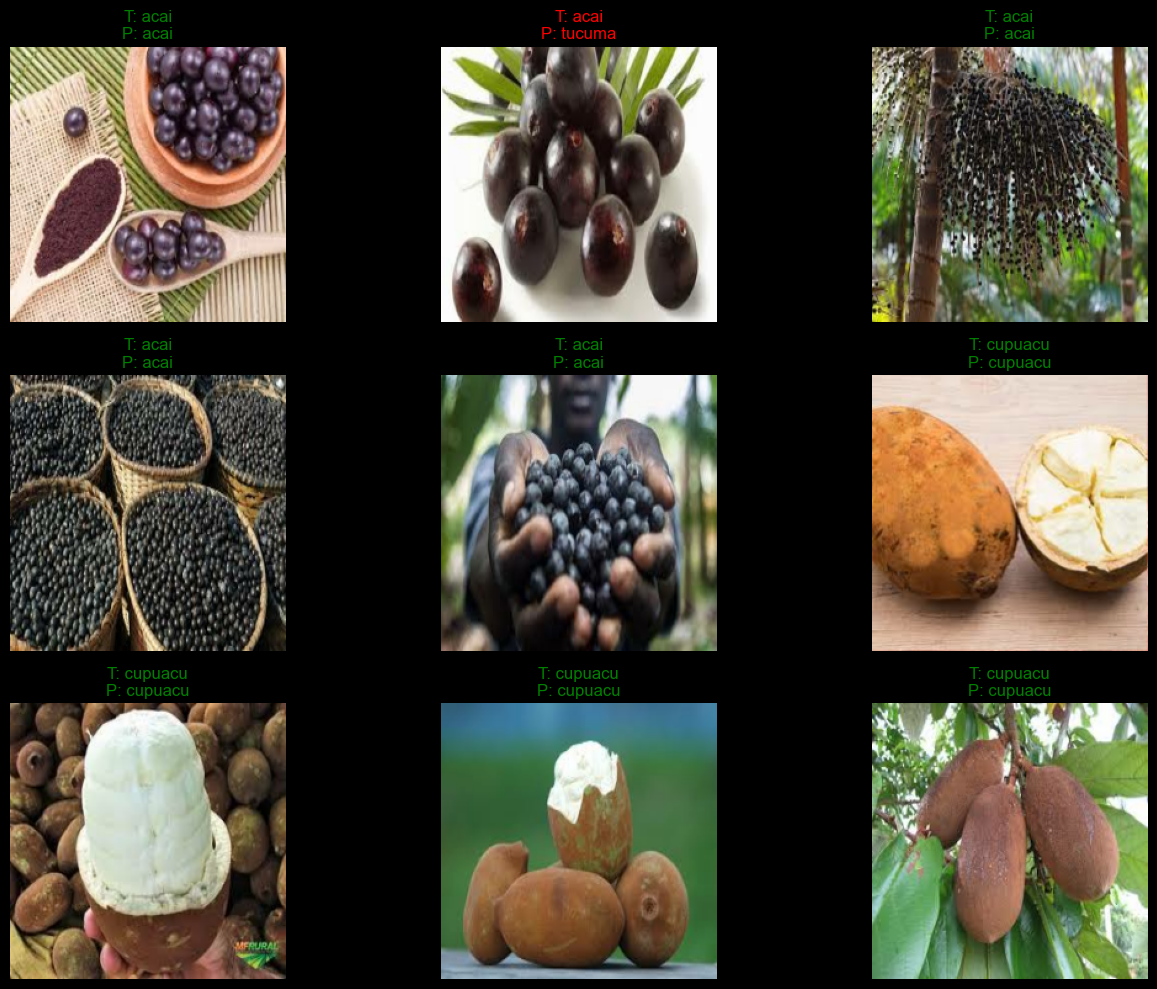

In [24]:
plt.figure(figsize=(14, 10))
for images, labels in transfer_test_ds.take(1):
    preds = vgg_model.predict(images, verbose=0)
    pred_labels = np.argmax(preds, axis=1)

    for i in range(min(9, len(images))):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        true_name = class_names[int(labels[i])]
        pred_name = class_names[int(pred_labels[i])]
        color = "green" if true_name == pred_name else "red"
        plt.title(f"T: {true_name}\nP: {pred_name}", color=color)
        plt.axis("off")
plt.tight_layout()
plt.show()



## 25. Save the VGG16 Model

In [25]:

vgg_model_path = Path("fruit_vgg16_transfer_final.keras")
vgg_model.save(vgg_model_path)
print("Saved VGG16 model to:", vgg_model_path.resolve())

Saved VGG16 model to: D:\Herald College SEM-6\Artificial Intelligence and Machine Learning\workshop\Workshop6\fruit_vgg16_transfer_final.keras


## 26. Compare Both Models

In [26]:
print("Model Comparison")
print("-" * 40)
print(f"Custom CNN Test Accuracy : {custom_test_acc:.4f}")
print(f"VGG16 Test Accuracy      : {vgg_test_acc:.4f}")

if vgg_test_acc > custom_test_acc:
    print("Observation: Transfer learning with VGG16 performed better on the test dataset.")
else:
    print("Observation: The custom CNN matched or outperformed the transfer-learning model.")



Model Comparison
----------------------------------------
Custom CNN Test Accuracy : 0.6000
VGG16 Test Accuracy      : 0.8333
Observation: Transfer learning with VGG16 performed better on the test dataset.


## 27. Final Notes for Submission

For your worksheet submission, include:
- dataset verification
- corrupted image checking
- class distribution
- random image visualization
- balanced stratified validation split
- training curves for both models
- evaluation metrics and classification reports
- a short conclusion explaining why VGG16 performed better on this small dataset

Practical conclusion:
- The original low accuracy came from a **tiny dataset**, an **imbalanced validation split**, and an **oversized scratch CNN**.
- The corrected notebook keeps the scratch model as a reasonable baseline and uses **VGG16 transfer learning** as the stronger final model.

